# Geographic Data Exploration and Spatial Cross-Validation Planning

This notebook explores the training data for geographic aquaculture suitability modeling. We'll:
1. Load and inspect the training data
2. Visualize geographic distribution of labels
3. Analyze spatial patterns
4. Plan spatial cross-validation strategy to avoid leakage

**Note**: Tree-based models (Random Forest, XGBoost) are planned for modeling due to their ability to handle spatial relationships and non-linear patterns.

In [ ]:
# Import necessary libraries
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import seaborn as sns
from scipy.spatial.distance import pdist, squareform, cdist
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
import hdbscan
from shapely.geometry import Polygon, box, Point
from shapely.ops import unary_union
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## 1. Load and Inspect Training Data

In [7]:
# Load the training data
train_df = pd.read_csv('../data/Train.csv')

# Basic information
print("Dataset Shape:", train_df.shape)
print("\nColumn Names:")
print(train_df.columns.tolist())
print("\nData Types:")
print(train_df.dtypes)
print("\nMissing Values:")
print(train_df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
display(train_df.describe())

Dataset Shape: (963, 148)

Column Names:
['ID', 'lon', 'lat', 'label', 'VH_01', 'VV_01', 'blue_01', 'green_01', 'nir_01', 'nira_01', 're1_01', 're2_01', 're3_01', 'red_01', 'swir1_01', 'swir2_01', 'VH_02', 'VV_02', 'blue_02', 'green_02', 'nir_02', 'nira_02', 're1_02', 're2_02', 're3_02', 'red_02', 'swir1_02', 'swir2_02', 'VH_03', 'VV_03', 'blue_03', 'green_03', 'nir_03', 'nira_03', 're1_03', 're2_03', 're3_03', 'red_03', 'swir1_03', 'swir2_03', 'VH_04', 'VV_04', 'blue_04', 'green_04', 'nir_04', 'nira_04', 're1_04', 're2_04', 're3_04', 'red_04', 'swir1_04', 'swir2_04', 'VH_05', 'VV_05', 'blue_05', 'green_05', 'nir_05', 'nira_05', 're1_05', 're2_05', 're3_05', 'red_05', 'swir1_05', 'swir2_05', 'VH_06', 'VV_06', 'blue_06', 'green_06', 'nir_06', 'nira_06', 're1_06', 're2_06', 're3_06', 'red_06', 'swir1_06', 'swir2_06', 'VH_07', 'VV_07', 'blue_07', 'green_07', 'nir_07', 'nira_07', 're1_07', 're2_07', 're3_07', 'red_07', 'swir1_07', 'swir2_07', 'VH_08', 'VV_08', 'blue_08', 'green_08', 'nir_0

,lon,lat,label,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
count,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,...,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000
mean,48.664170,39.617558,0.408100,-25.793902,-15.394309,1636.611630,1827.134995,2220.440291,2184.444444,2041.531672,...,1595.956386,1804.764278,2127.965732,2104.314642,1998.521288,2022.935618,2065.710280,1779.303219,2168.557632,1889.936656
std,0.280006,0.240640,0.491737,5.777613,6.057236,268.122006,347.717222,833.369028,834.768546,470.712725,...,220.150436,291.663559,745.271396,754.528296,394.900064,617.320019,668.274618,315.867218,868.677221,683.347786
min,48.050211,39.056817,0.000000,-48.143182,-31.912804,1114.000000,1152.000000,1059.000000,1040.000000,1124.000000,...,1120.000000,1160.000000,1076.000000,1081.000000,1159.000000,1086.000000,1084.000000,1122.000000,1048.000000,1040.000000
25%,48.484232,39.450100,0.000000,-30.205697,-21.707632,1448.500000,1620.000000,1383.500000,1294.000000,1716.500000,...,1436.000000,1598.500000,1388.500000,1313.000000,1728.500000,1439.500000,1427.500000,1570.500000,1177.500000,1130.500000
50%,48.727900,39.535260,0.000000,-24.532436,-13.193132,1625.000000,1800.000000,2308.000000,2308.000000,2058.000000,...,1579.000000,1776.000000,2220.000000,2236.000000,2011.000000,2071.000000,2131.000000,1801.000000,2409.000000,2002.000000
75%,48.863635,39.801161,1.000000,-21.202756,-10.694560,1808.000000,2056.000000,2783.000000,2758.500000,2356.000000,...,1734.000000,2005.500000,2600.000000,2594.000000,2244.000000,2396.500000,2467.000000,1972.000000,2906.500000,2487.500000
max,49.175171,40.172345,1.000000,-10.719378,6.227268,2748.000000,3133.000000,6722.000000,6528.000000,3635.000000,...,2463.000000,2748.000000,6832.000000,6051.000000,3228.000000,5485.000000,5960.000000,2822.000000,4505.000000,3878.000000


## 2. Label Distribution Analysis

Label Distribution:
label
0    570
1    393
Name: count, dtype: int64

Label Percentages:
label
0    59.190031
1    40.809969
Name: proportion, dtype: float64


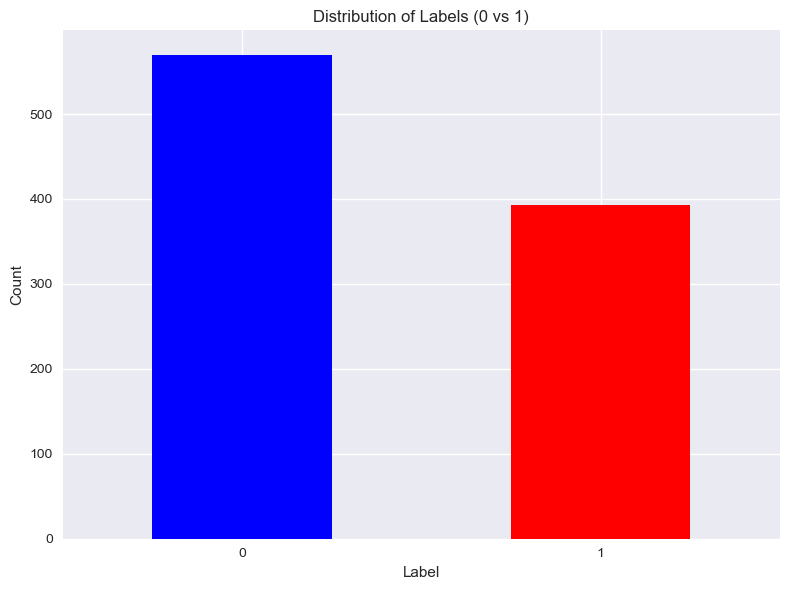

In [8]:
# Check label distribution
label_counts = train_df['label'].value_counts()
print("Label Distribution:")
print(label_counts)
print("\nLabel Percentages:")
print(train_df['label'].value_counts(normalize=True) * 100)

# Create a simple bar plot
plt.figure(figsize=(8, 6))
label_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Distribution of Labels (0 vs 1)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Geographic Visualization

Create a scatter plot of longitude vs latitude, colored by label (blue=0, red=1)

Available columns containing 'lon' or 'lat':
['lon', 'lat']
Using 'lon' for longitude and 'lat' for latitude


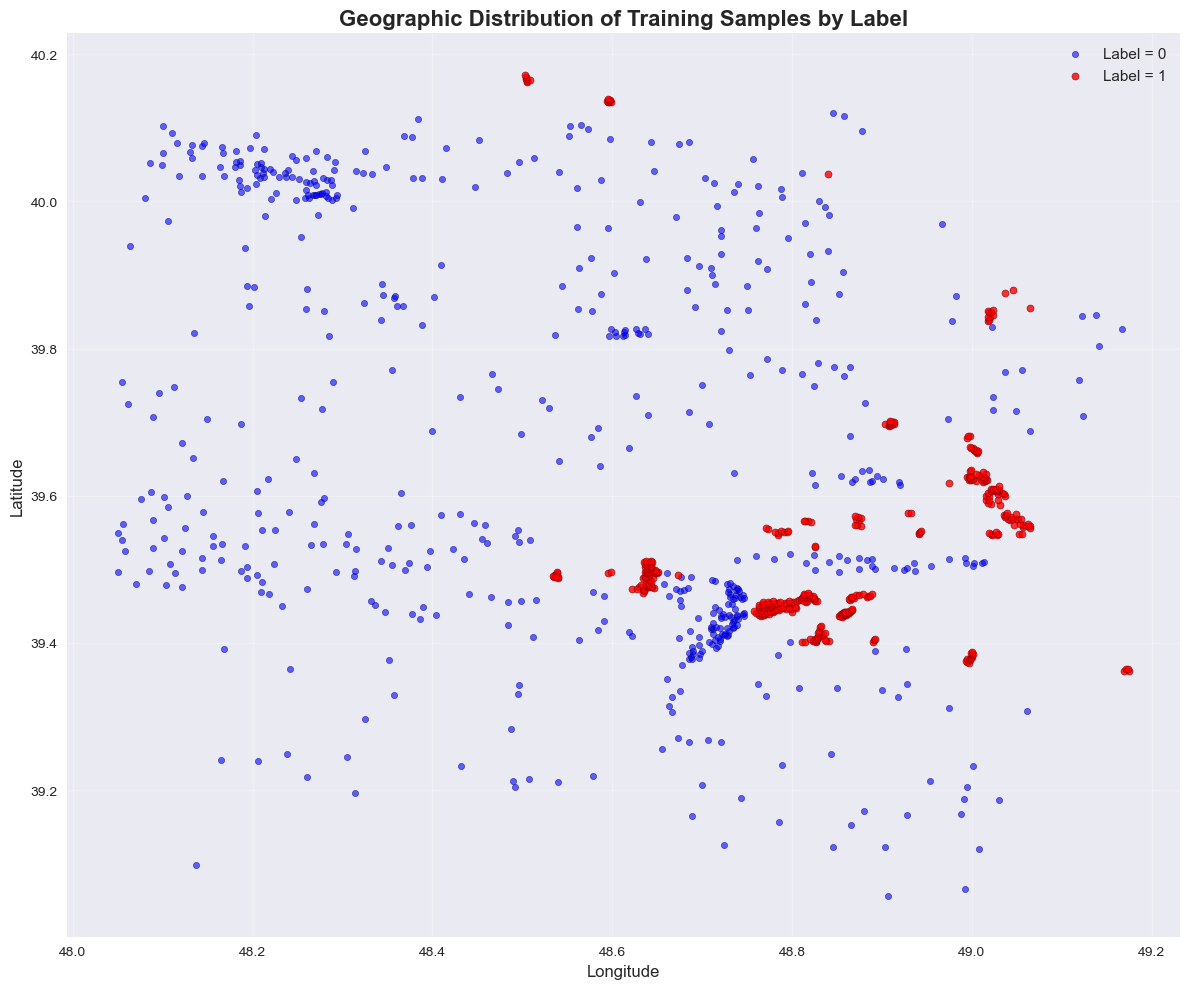


Label=0 points: 570
Label=1 points: 393
Longitude range: 48.0502 to 49.1752
Latitude range: 39.0568 to 40.1723
Exported 963 points to all_points.kml (label=0: blue, label=1: red)


In [18]:
# Check if longitude and latitude columns exist
print("Available columns containing 'lon' or 'lat':")
lon_lat_cols = [col for col in train_df.columns if 'lon' in col.lower() or 'lat' in col.lower()]
print(lon_lat_cols)

# Assuming columns are named 'lon' and 'lat' - adjust if needed
if 'lon' in train_df.columns and 'lat' in train_df.columns:
    lon_col = 'lon'
    lat_col = 'lat'
else:
    # Use first matching columns
    lon_col = lon_lat_cols[0] if lon_lat_cols else None
    lat_col = lon_lat_cols[1] if len(lon_lat_cols) > 1 else None

if lon_col and lat_col:
    print(f"Using '{lon_col}' for longitude and '{lat_col}' for latitude")
    
    # Create the scatter plot
    plt.figure(figsize=(12, 10))
    
    # Plot label=0 points in blue
    mask_0 = train_df['label'] == 0
    plt.scatter(train_df.loc[mask_0, lon_col], train_df.loc[mask_0, lat_col], 
                c='blue', alpha=0.6, s=20, label='Label = 0', edgecolors='navy', linewidth=0.5)
    
    # Plot label=1 points in red
    mask_1 = train_df['label'] == 1
    plt.scatter(train_df.loc[mask_1, lon_col], train_df.loc[mask_1, lat_col], 
                c='red', alpha=0.8, s=25, label='Label = 1', edgecolors='darkred', linewidth=0.5)
    
    plt.title('Geographic Distribution of Training Samples by Label', fontsize=16, fontweight='bold')
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"\nLabel=0 points: {mask_0.sum()}")
    print(f"Label=1 points: {mask_1.sum()}")
    print(f"Longitude range: {train_df[lon_col].min():.4f} to {train_df[lon_col].max():.4f}")
    print(f"Latitude range: {train_df[lat_col].min():.4f} to {train_df[lat_col].max():.4f}")
    
    # Export all points to KML with colored icons based on label
    kml_header = '''<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <Document>
    <name>All Points</name>
    <description>All points from aquaculture dataset with label-based coloring</description>
    <Style id="style0">
      <IconStyle>
        <color>ff0000ff</color>  <!-- blue in ABGR -->
        <scale>0.8</scale>
        <Icon>
          <href>http://maps.google.com/mapfiles/kml/paddle/blu-blank.png</href>
        </Icon>
      </IconStyle>
    </Style>
    <Style id="style1">
      <IconStyle>
        <color>ffff0000</color>  <!-- red in ABGR -->
        <scale>0.8</scale>
        <Icon>
          <href>http://maps.google.com/mapfiles/kml/paddle/red-blank.png</href>
        </Icon>
      </IconStyle>
    </Style>
'''
    kml_placemarks = ''
    for idx, row in train_df.iterrows():
        lon_val = row[lon_col]
        lat_val = row[lat_col]
        label_val = row['label']
        # Use index as name or maybe use ID if available
        name = f"Point {idx}"
        if 'ID' in train_df.columns:
            name = f"ID_{row['ID']}"
        style_url = "#style0" if label_val == 0 else "#style1"
        kml_placemarks += f'''    <Placemark>
      <name>{name}</name>
      <styleUrl>{style_url}</styleUrl>
      <Point>
        <coordinates>{lon_val},{lat_val},0</coordinates>
      </Point>
    </Placemark>
'''
    kml_footer = '''  </Document>
</kml>'''
    kml_content = kml_header + kml_placemarks + kml_footer
    kml_filename = 'all_points.kml'
    with open(kml_filename, 'w') as f:
        f.write(kml_content)
    print(f"Exported {len(train_df)} points to {kml_filename} (label=0: blue, label=1: red)")
else:
    print("Longitude or latitude columns not found. Please check column names.")

## 4. Spatial Cross-Validation Strategy

### Why Regular Cross-Validation Causes Leakage

In geographic data, nearby points tend to have similar labels due to spatial autocorrelation. If we use regular k-fold cross-validation:
- Training and test points that are geographically close may end up in different folds
- This leads to overoptimistic performance estimates because the model is tested on points very similar to those it was trained on
- Known as 'spatial leakage' or 'spatial autocorrelation bias'

### Recommended Spatial Cross-Validation Approaches

**Option 1: Spatial Blocking (Recommended)**
- Divide the study area into spatial blocks (grid cells)
- Assign all points within each block to the same fold
- Ensures minimum distance between training and test points
- Block size should be larger than the spatial autocorrelation range

**Option 2: Buffer-Based Splitting**
- For each test point, exclude all training points within a specified distance buffer
- More computationally intensive but provides strong guarantee against leakage

**Option 3: Using Existing Libraries**
- `scikit-learn`'s `GroupKFold` or `StratifiedGroupKFold` with spatial groups
- Specialized libraries like `sperrorest` (R) or custom Python implementations

### Implementation Plan for Spatial Blocking:

1. **Determine optimal block size**:
   - Calculate spatial autocorrelation (Moran's I) or variogram to find range
   - Alternatively, use domain knowledge about expected spatial scale of processes

2. **Create spatial blocks**:
   - Divide longitude/latitude range into regular grid
   - Assign each point to a grid cell based on its coordinates
   - Use grid cell ID as grouping variable

3. **Apply GroupKFold or StratifiedGroupKFold**:
   - Use sklearn's GroupKFold or StratifiedGroupKFold with grid cell IDs as groups
   - Ensures all points from same grid cell are in same fold
   - StratifiedGroupKFold additionally maintains class balance across folds

4. **Validate the approach**:
   - Check minimum distance between train/test points in each fold
   - Examine spatial autocorrelation in model residuals

### Next Steps:
- Implement spatial blocking cross-validation
- Train tree-based models (Random Forest, XGBoost, LightGBM)
- Compare performance with and without spatial CV
- Feature engineering: distance to nearest label=1, local density, etc.

## 5. Summary and Next Steps

**Key Findings from Data Exploration:**
- [To be filled after running the notebook]
- Label distribution: [percentage]% label=1, [percentage]% label=0
- Geographic extent: [lon_range] longitude, [lat_range] latitude
- Spatial patterns: [description of label=1 clustering]

**Recommended Cross-Validation Approach:**
Use spatial blocking with StratifiedGroupKFold to prevent spatial leakage while maintaining class balance. Block size should be determined based on:
1. Empirical spatial autocorrelation analysis (variogram/Moran's I)
2. Domain knowledge about spatial processes in aquaculture suitability
3. Sensitivity analysis with different block sizes

**Immediate Next Steps:**
1. Run the notebook to complete exploratory analysis
2. Determine optimal spatial block size
3. Implement spatial cross-validation
4. Baseline model training with tree-based algorithms
5. Feature engineering for spatial context

## 6. Spatial Autocorrelation Analysis (in UTM)

We'll first convert the data to a GeoDataFrame in UTM CRS (EPSG:4326 -> appropriate UTM zone) to perform spatial analysis in meters.
We'll examine spatial autocorrelation in the label variable using Moran's I and a variogram to understand the spatial scale of dependence.

Converted 963 points to UTM zone 32639
Moran's I for labels: 0.4023
Expected Moran's I under no autocorrelation: -0.0010
Pseudo p-value from 999 permutations: 0.0010


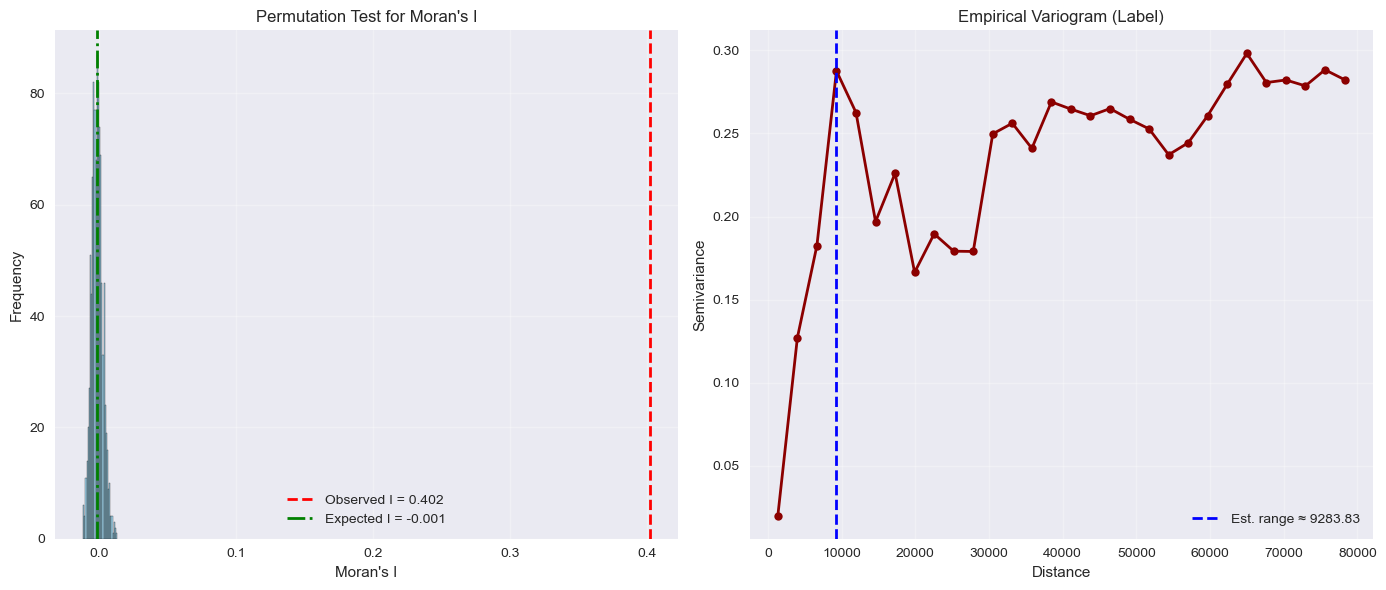


Variogram analysis (max lag = 79575.67):
Number of distance bins: 30
Average semivariance (sill): 0.2981
Estimated range (distance where semivariance reaches 95% of sill): 9283.83

Suggested spatial block size for blocking: 9283.83 meters
(This is roughly the spatial autocorrelation range; blocks should be larger than this to minimize leakage)


In [ ]:
# Create GeoDataFrame from the existing train_df (which is a pandas DataFrame)
gdf = gpd.GeoDataFrame(train_df, geometry=gpd.points_from_xy(train_df[lon_col], train_df[lat_col]), crs="EPSG:4326")

# Determine UTM zone from the centroid
centroid = gdf.geometry.unary_union.centroid
lon_centroid = centroid.x
lat_centroid = centroid.y

zone_number = int((lon_centroid + 180) / 6) + 1
if lat_centroid >= 0:
    epsg_code = 32600 + zone_number
else:
    epsg_code = 32700 + zone_number

# Convert to UTM
gdf_utm = gdf.to_crs(epsg_code)

# Extract UTM coordinates and add to train_df
train_df['utm_x'] = gdf_utm.geometry.x
train_df['utm_y'] = gdf_utm.geometry.y

# Set the coordinate columns for the analysis
utm_x_col = 'utm_x'
utm_y_col = 'utm_y'

print(f"Converted {len(train_df)} points to UTM zone {epsg_code}")

# Spatial autocorrelation analysis: Moran's I and variogram

# Extract coordinates and label
coords = train_df[[utm_x_col, utm_y_col]].values
labels = train_df['label'].values

# Compute pairwise Euclidean distances
distances = squareform(pdist(coords, metric='euclidean'))

# Moran's I implementation
def morans_i(values, weights):
    """
    Calculate Moran's I statistic for spatial autocorrelation.
    values: 1D array of attribute values
    weights: 2D weights matrix (row-standardized preferred)
    """
    n = len(values)
    mean_val = np.mean(values)
    deviations = values - mean_val
    
    # Numerator: sum over i,j w_ij * (x_i - mean) * (x_j - mean)
    num = np.sum(weights * np.outer(deviations, deviations))
    
    # Denominator: sum over i (x_i - mean)^2
    den = np.sum(deviations ** 2)
    
    # Sum of weights
    sum_w = np.sum(weights)
    
    if den == 0 or sum_w == 0:
        return np.nan
    
    I = (n / sum_w) * (num / den)
    return I

# Create distance-based weights matrix (inverse distance, with cutoff)
# We'll use inverse distance with a threshold to avoid very large weights
max_dist = np.max(distances)
# Set weights to inverse distance, but set self-weights to 0
with np.errstate(divide='ignore', invalid='ignore'):
    weights = 1 / distances
np.fill_diagonal(weights, 0)  # remove self weights
# Optional: apply a cutoff distance (e.g., distance at 95th percentile) to focus on local autocorrelation
cutoff = np.percentile(distances[distances > 0], 95)
weights[distances > cutoff] = 0

# Row-standardize weights (each row sums to 1)
row_sums = weights.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
weights_std = weights / row_sums

# Calculate Moran's I for labels
I_label = morans_i(labels, weights_std)
print(f"Moran's I for labels: {I_label:.4f}")

# Expected Moran's I under no spatial autocorrelation: -1/(n-1)
expected_I = -1 / (len(labels) - 1)
print(f"Expected Moran's I under no autocorrelation: {expected_I:.4f}")

# Permutation test for significance (optional, simplified)
# We'll do a simple approximation: compare to random permutations
n_perm = 999
I_perm = np.zeros(n_perm)
for i in range(n_perm):
    perm_labels = np.random.permutation(labels)
    I_perm[i] = morans_i(perm_labels, weights_std)
    
# Calculate pseudo p-value
p_value = (np.sum(I_perm >= I_label) + 1) / (n_perm + 1)
print(f"Pseudo p-value from {n_perm} permutations: {p_value:.4f}")

# Variogram analysis
# Bin distances and compute average semivariance
def variogram(values, distances, max_lag=None, n_bins=15):
    """
    Compute empirical variogram.
    values: 1D array
    distances: 2D distance matrix
    max_lag: maximum distance to consider (default: max distance)
    n_bins: number of distance bins
    """
    if max_lag is None:
        max_lag = np.max(distances)
    
    # Extract upper triangle (excluding diagonal)
    triu_indices = np.triu_indices_from(distances, k=1)
    dist_vec = distances[triu_indices]
    # Semivariance: 0.5 * (value_i - value_j)^2
    semivar_vec = 0.5 * (values[triu_indices[0]] - values[triu_indices[1]]) ** 2
    
    # Filter by max_lag
    mask = dist_vec <= max_lag
    dist_vec = dist_vec[mask]
    semivar_vec = semivar_vec[mask]
    
    # Create bins
    bins = np.linspace(0, max_lag, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    gamma = np.zeros(n_bins)
    count = np.zeros(n_bins)
    
    for i in range(n_bins):
        bin_mask = (dist_vec >= bins[i]) & (dist_vec < bins[i+1])
        if np.any(bin_mask):
            gamma[i] = np.mean(semivar_vec[bin_mask])
            count[i] = np.sum(bin_mask)
        else:
            gamma[i] = np.nan
    
    return bin_centers, gamma, count

# Compute variogram for labels
max_lag_var = np.percentile(distances[distances > 0], 90)  # use 90th percentile to avoid noisy distant bins
bin_centers, gamma, count = variogram(labels, distances, max_lag=max_lag_var, n_bins=15)

# Plot Moran's I result and variogram
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Moran's I visualization: histogram of permuted I with observed value
axes[0].hist(I_perm, bins=30, alpha=0.7, edgecolor='black', color='skyblue')
axes[0].axvline(I_label, color='red', linestyle='--', linewidth=2, label=f'Observed I = {I_label:.3f}')
axes[0].axvline(expected_I, color='green', linestyle='-.', linewidth=2, label=f'Expected I = {expected_I:.3f}')
axes[0].set_xlabel("Moran's I")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Permutation Test for Moran's I")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Variogram
axes[1].plot(bin_centers, gamma, 'o-', color='darkred', linewidth=2, markersize=6)
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Semivariance")
axes[1].set_title("Empirical Variogram (Label)")
axes[1].grid(True, alpha=0.3)

# Add vertical line where variogram stabilizes (rough estimate of range)
# Find where variogram reaches 95% of sill (max semivariance)
sill = np.nanmax(gamma)
if not np.isnan(sill):
    sill_level = 0.95 * sill
    # Find first bin where gamma >= sill_level
    above_sill = np.where(gamma >= sill_level)[0]
    if len(above_sill) > 0:
        range_est = bin_centers[above_sill[0]]
        axes[1].axvline(range_est, color='blue', linestyle='--', linewidth=2, label=f'Est. range ≈ {range_est:.2f}')
        axes[1].legend()

plt.tight_layout()
plt.show()

# Print variogram info
print(f"\nVariogram analysis (max lag = {max_lag_var:.2f}):")
print(f"Number of distance bins: {len(bin_centers)}")
print(f"Average semivariance (sill): {sill:.4f}" if not np.isnan(sill) else "Sill: NaN")
if not np.isnan(sill) and len(above_sill) > 0:
    print(f"Estimated range (distance where semivariance reaches 95% of sill): {range_est:.2f}")
else:
    print("Could not estimate range from variogram.")

# Suggestion for spatial block size
suggested_block_size = range_est if not np.isnan(range_est) else max_lag_var / 2
print(f"\nSuggested spatial block size for blocking: {suggested_block_size:.2f} meters")
print("(This is roughly the spatial autocorrelation range; blocks should be larger than this to minimize leakage)")

## 7. Spatial Blocking with StratifiedGroupKFold (UTM)

We'll implement spatial blocking to create spatial groups for cross-validation, preventing spatial leakage by ensuring training and test points are separated by at least the block size. Note: we are using UTM coordinates (meters) for this analysis.
NOTE: This section assumes the previous cell (Spatial Autocorrelation Analysis) has been run first to determine the suggested block size.


=== Spatial Blocking with StratifiedGroupKFold ===
Using suggested block size from Section 6: 9283.828 meters
Using user-specified block size: 10000.000 meters
Creating 10 x 13 = 130 spatial blocks
Number of unique spatial groups: 100
Group ID range: 0 to 124
Group sizes: min=1, max=109, mean=9.6


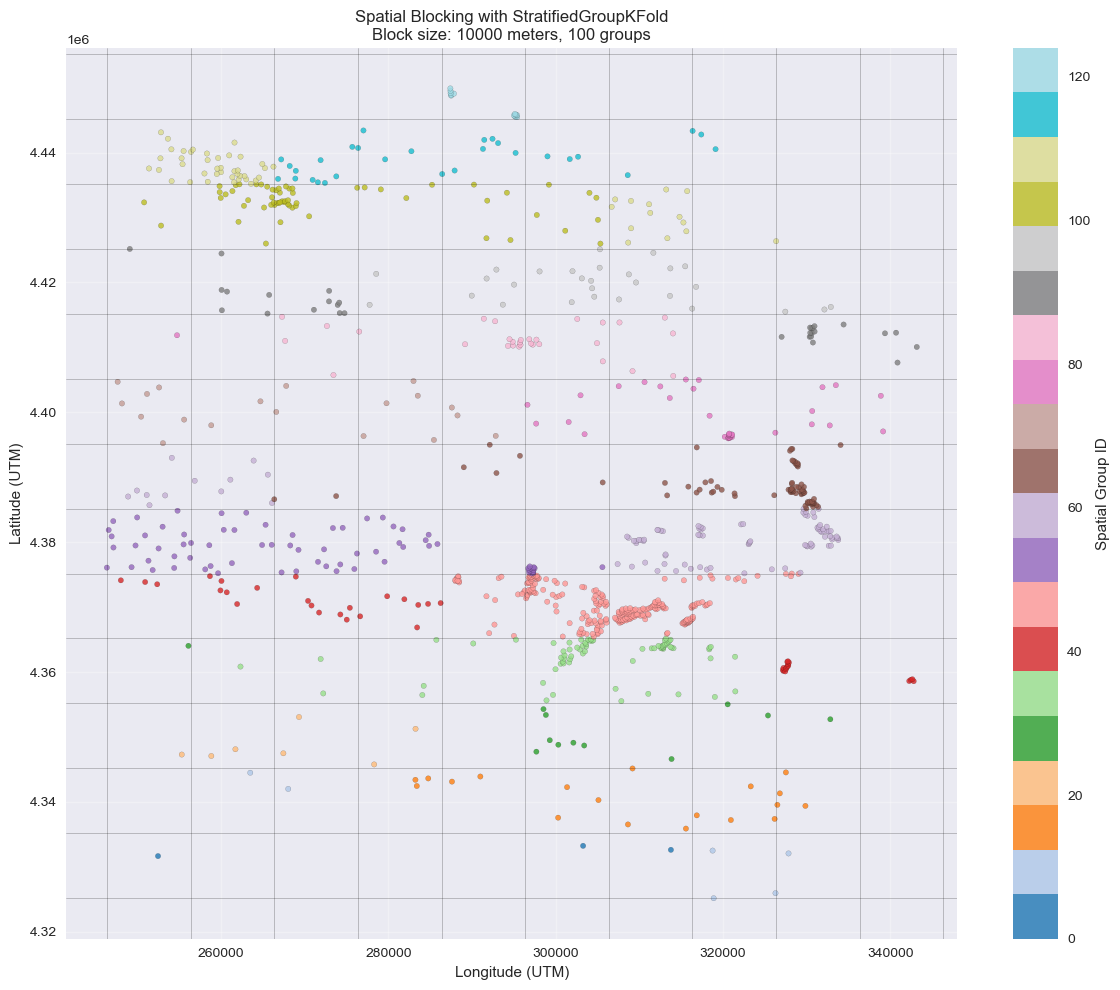


Performing 5-fold StratifiedGroupKFold cross-validation...
Number of samples: 963
Number of features: 147
Fold 1: Train=742, Test=221, Min train-test distance=134.773, Train label mean=0.384, Test label mean=0.489
Fold 2: Train=775, Test=188, Min train-test distance=147.763, Train label mean=0.412, Test label mean=0.394
Fold 3: Train=776, Test=187, Min train-test distance=331.480, Train label mean=0.411, Test label mean=0.396
Fold 4: Train=776, Test=187, Min train-test distance=134.773, Train label mean=0.411, Test label mean=0.396
Fold 5: Train=783, Test=180, Min train-test distance=483.256, Train label mean=0.421, Test label mean=0.350


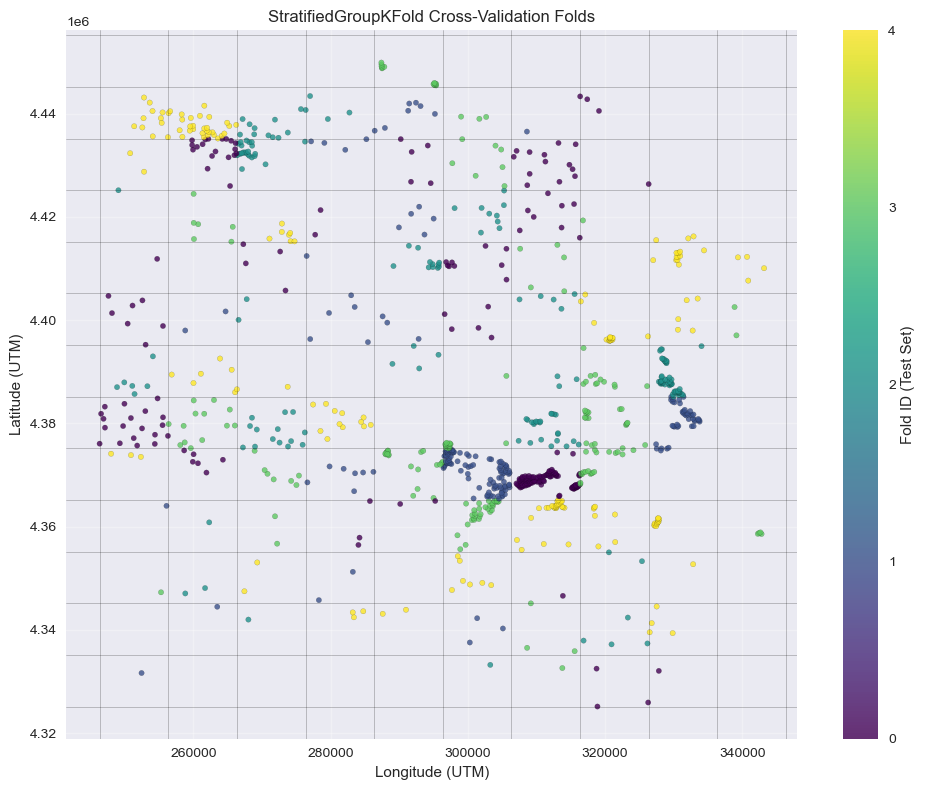


Minimum train-test distance per fold: ['134.773', '147.763', '331.480', '134.773', '483.256']
Overall minimum train-test distance: 134.773
Mean minimum train-test distance: 246.409

Expected minimum distance (block size): 10000.000 meters
Actual minimum distance achieved: 134.773 meters
Ratio of actual to expected: 0.01

Spatial groups ready for use in Section 8 (Buffer-Enhanced Cross-Validation)
Saved train_df with spatial groups to: ../spatial_blocks/Train_with_spatial_groups_block_size_10000.0.csv


In [37]:
# Spatial Blocking with StratifiedGroupKFold Implementation
# NOTE: This assumes the UTM coordinates have been calculated in Section 6

print("\n=== Spatial Blocking with StratifiedGroupKFold ===")

# Get coordinates (UTM)
coords = train_df[[utm_x_col, utm_y_col]].values

# Use suggested block size from variogram analysis in Section 6 as default
# but allow user to specify a custom value
# Check if suggested_block_size was calculated in Section 6
if 'suggested_block_size' in locals():
    default_block_size = suggested_block_size
    print(f"Using suggested block size from Section 6: {default_block_size:.3f} meters")
else:
    # Fallback if Section 6 didn't run or didn't define suggested_block_size
    default_block_size = 10000.0
    print(f"Section 6 not run or suggested_block_size not available, using default: {default_block_size:.3f} meters")

# Allow user to override the block size
# Set this to a custom value to override, or None to use the default from Section 6
user_block_size = 10000.0  # Change this value to specify a custom block size in meters
if user_block_size is not None:
    block_size = user_block_size
    print(f"Using user-specified block size: {block_size:.3f} meters")
else:
    block_size = default_block_size
    print(f"Using block size: {block_size:.3f} meters")

# Create spatial blocks based on UTM coordinates
lons = train_df[utm_x_col].values
lats = train_df[utm_y_col].values
lon_min, lon_max = lons.min(), lons.max()
lat_min, lat_max = lats.min(), lats.max()

# Calculate number of blocks in each direction
n_lon_blocks = int(np.ceil((lon_max - lon_min) / block_size))
n_lat_blocks = int(np.ceil((lat_max - lat_min) / block_size))

print(f"Creating {n_lon_blocks} x {n_lat_blocks} = {n_lon_blocks * n_lat_blocks} spatial blocks")

# Assign each point to a block
# Block ID = lat_block_index * n_lon_blocks + lon_block_index
lat_block_indices = np.floor((lats - lat_min) / block_size).astype(int)
lon_block_indices = np.floor((lons - lon_min) / block_size).astype(int)
# Ensure indices are within bounds
lat_block_indices = np.clip(lat_block_indices, 0, n_lat_blocks - 1)
lon_block_indices = np.clip(lon_block_indices, 0, n_lon_blocks - 1)

# Create spatial group IDs
spatial_groups = lat_block_indices * n_lon_blocks + lon_block_indices

# Store the groups
train_df['spatial_group'] = spatial_groups

# Verify the groups
unique_groups = np.unique(train_df['spatial_group'])
n_groups = len(unique_groups)
print(f"Number of unique spatial groups: {n_groups}")
print(f"Group ID range: {unique_groups.min()} to {unique_groups.max()}")

# Check group sizes
group_sizes = []
for group_id in unique_groups:
    size = np.sum(train_df['spatial_group'] == group_id)
    group_sizes.append(size)
print(f"Group sizes: min={min(group_sizes)}, max={max(group_sizes)}, mean={np.mean(group_sizes):.1f}")

# Visualize the spatial blocks
plt.figure(figsize=(12, 10))

# Create a color map for groups
colors = plt.cm.tab20(np.linspace(0, 1, max(20, n_groups)))

sc = plt.scatter(coords[:, 0], coords[:, 1],
                 c=train_df['spatial_group'],
                 cmap='tab20',
                 s=15,
                 alpha=0.8,
                 edgecolors='k',
                 linewidth=0.1,
                 zorder=2)

# Add colorbar if reasonable number of groups
if n_groups <= 20:
    cbar = plt.colorbar(sc, ticks=range(n_groups))
    cbar.set_label('Spatial Group ID')
else:
    cbar = plt.colorbar(sc)
    cbar.set_label('Spatial Group ID')

plt.xlabel('Longitude (UTM)')
plt.ylabel('Latitude (UTM)')
plt.title(f'Spatial Blocking with StratifiedGroupKFold\n'
          f'Block size: {block_size:.0f} meters, {n_groups} groups')
plt.grid(True, alpha=0.3)

# Draw block boundaries
for i in range(n_lon_blocks + 1):
    x = lon_min + i * block_size
    plt.axvline(x, color='black', linewidth=0.5, alpha=0.3)
for j in range(n_lat_blocks + 1):
    y = lat_min + j * block_size
    plt.axhline(y, color='black', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply StratifiedGroupKFold cross-validation
n_splits = 5
skf = StratifiedGroupKFold(n_splits=n_splits)

# Prepare features and target
feature_cols = [col for col in train_df.columns if col not in ['label', utm_x_col, utm_y_col, 'spatial_group']]
if len(feature_cols) == 0:
    feature_cols = [utm_x_col, utm_y_col]
    print("Warning: Using coordinates as features for demonstration only.")

X = train_df[feature_cols].values
y = train_df['label'].values
groups = train_df['spatial_group'].values

print(f"\nPerforming {n_splits}-fold StratifiedGroupKFold cross-validation...")
print(f"Number of samples: {len(X)}")
print(f"Number of features: {X.shape[1]}")

# Store fold information for visualization
fold_assignments = np.full(len(groups), -1)
fold_stats = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y, groups)):
    fold_assignments[test_idx] = fold
    
    # Calculate minimum distance between train and test points
    if len(train_idx) > 0 and len(test_idx) > 0:
        train_coords_fold = coords[train_idx]
        test_coords_fold = coords[test_idx]
        min_dist = np.min(cdist(train_coords_fold, test_coords_fold))
    else:
        min_dist = np.inf  # No valid training points
    
    # Calculate label distribution in train/test
    train_label_prop = np.mean(y[train_idx]) if len(train_idx) > 0 else 0
    test_label_prop = np.mean(y[test_idx])
    
    fold_stats.append({
        'fold': fold,
        'train_size': len(train_idx),
        'test_size': len(test_idx),
        'min_distance': min_dist,
        'train_label_mean': train_label_prop,
        'test_label_mean': test_label_prop,
        'train_indices': train_idx,
        'test_indices': test_idx
    })
    
    print(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}, "
          f"Min train-test distance={min_dist:.3f}, "
          f"Train label mean={train_label_prop:.3f}, Test label mean={test_label_prop:.3f}")

# Visualize StratifiedGroupKFold fold assignments
plt.figure(figsize=(10, 8))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=fold_assignments, cmap='viridis', s=15, alpha=0.8, edgecolors='k', linewidth=0.1, zorder=1)
cbar = plt.colorbar(sc, ticks=range(n_splits))
cbar.set_label('Fold ID (Test Set)')
plt.xlabel('Longitude (UTM)')
plt.ylabel('Latitude (UTM)')
plt.title('StratifiedGroupKFold Cross-Validation Folds')
plt.grid(True, alpha=0.3)

# Plot all block boundaries in black (light)
for i in range(n_lon_blocks + 1):
    x = lon_min + i * block_size
    plt.axvline(x, color='black', linewidth=0.5, alpha=0.3)
for j in range(n_lat_blocks + 1):
    y = lat_min + j * block_size
    plt.axhline(y, color='black', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary of minimum distances
min_dists = [stat['min_distance'] for stat in fold_stats if stat['min_distance'] != np.inf]
print(f"\nMinimum train-test distance per fold: {[f'{d:.3f}' for d in min_dists]}")
if min_dists:
    print(f"Overall minimum train-test distance: {np.min(min_dists):.3f}")
    print(f"Mean minimum train-test distance: {np.mean(min_dists):.3f}")
else:
    print("No valid training-test splits found.")

# Check if minimum distance is approximately >= block_size
if min_dists:
    print(f"\nExpected minimum distance (block size): {block_size:.3f} meters")
    print(f"Actual minimum distance achieved: {np.min(min_dists):.3f} meters")
    print(f"Ratio of actual to expected: {np.min(min_dists) / block_size:.2f}")

# Note for next section: The spatial groups are now stored in train_df['spatial_group']
# and will be used for the buffer-enhanced cross-validation in the next section
print(f"\nSpatial groups ready for use in Section 8 (Buffer-Enhanced Cross-Validation)")

# Save the train_df with spatial_group column to the spatial_blocks directory
spatial_blocks_dir = '../spatial_blocks'
os.makedirs(spatial_blocks_dir, exist_ok=True)
output_path = os.path.join(spatial_blocks_dir, f'Train_with_spatial_groups_block_size_{block_size}.csv')
train_df.to_csv(output_path, index=False)
print(f"Saved train_df with spatial groups to: {output_path}")

## 8. Spatial Blocking with HDBSCAN

We'll implement an alternative spatial blocking approach using HDBSCAN, a density-based clustering algorithm that can identify arbitrarily shaped clusters and detect noise (outliers). This method does not require pre-specifying a block size; instead, it determines clusters based on the density of points in UTM space.

### Concept: HDBSCAN-Based Spatial Blocking

The idea is to:
1. Use UTM coordinates (meters) as input to HDBSCAN.
2. Obtain cluster labels where each cluster represents a spatial block.
3. Points labeled as noise (-1) can be treated as a separate block or excluded, depending on the analysis.
4. Use these HDBSCAN-defined groups for cross-validation, ensuring that spatially cohesive regions are kept together.
5. This approach can capture complex spatial structures that fixed grid blocking may miss.

### Implementation Plan:

1. **Run HDBSCAN** on the UTM coordinates with a suitable `min_cluster_size`.
2. **Assign each point to a cluster** (label). Noise points receive label `-1`.
3. **Optionally remap noise** to a unique group ID if desired for cross-validation.
4. **Visualize the resulting clusters** to inspect the spatial blocking pattern.
5. **Proceed to buffer-enhanced cross-validation** (Section 9) using these HDBSCAN groups as the spatial blocking foundation.


=== Spatial Blocking with HDBSCAN ===
Clustering 963 points using HDBSCAN...
Coordinate ranges: utm_x [246347.2, 343157.2], utm_y [4325166.9, 4449875.3]
Using min_cluster_size = 48 (~5.0% of data)

HDBSCAN Results:
Number of clusters found: 3
Number of noise points: 434 (45.1%)
Cluster sizes: min=96, max=330, mean=176.3
Noise points assigned to group ID: 3
Total number of groups for CV: 4
Group IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


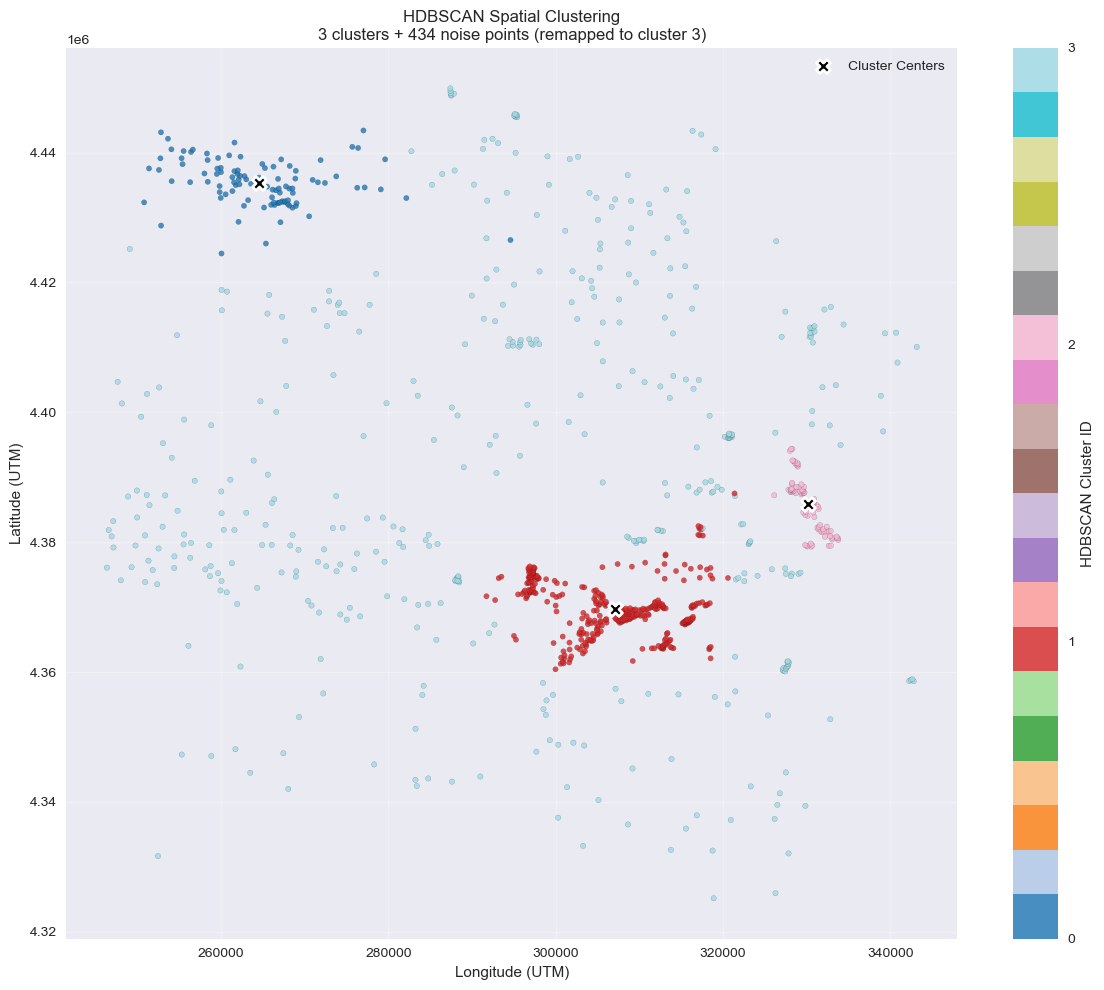


Cluster characteristics:
Average cluster radius: 5701.3 meters
Radius range: 3515.0 - 7206.1 meters

HDBSCAN spatial groups ready for use in Section 9 (Buffer-Enhanced Cross-Validation)
Saved train_df with HDBSCAN groups to: ../spatial_blocks/Train_with_hdbscan_groups.csv


In [36]:
# HDBSCAN Spatial Blocking Implementation
# NOTE: This assumes the UTM coordinates have been calculated in Section 6
# and will overwrite the spatial_group column from Section 7 if it exists

print("\n=== Spatial Blocking with HDBSCAN ===")

# Use UTM coordinates for clustering
coords_utm = train_df[['utm_x', 'utm_y']].values

print(f"Clustering {len(coords_utm)} points using HDBSCAN...")
print(f"Coordinate ranges: utm_x [{coords_utm[:,0].min():.1f}, {coords_utm[:,0].max():.1f}], "
      f"utm_y [{coords_utm[:,1].min():.1f}, {coords_utm[:,1].max():.1f}]")

# Determine min_cluster_size
# A common heuristic is to set it to ~5% of the total number of points
# but not less than a minimum threshold (e.g., 5)
min_cluster_size = max(5, len(coords_utm) // 20)
print(f"Using min_cluster_size = {min_cluster_size} (~{min_cluster_size/len(coords_utm)*100:.1f}% of data)")

# Run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean')
cluster_labels = clusterer.fit_predict(coords_utm)

# Analyze results
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"\nHDBSCAN Results:")
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(cluster_labels)*100:.1f}%)")

if n_clusters > 0:
    # Get sizes of each cluster (excluding noise)
    unique_labels = [l for l in set(cluster_labels) if l != -1]
    cluster_sizes = [list(cluster_labels).count(l) for l in unique_labels]
    print(f"Cluster sizes: min={min(cluster_sizes)}, max={max(cluster_sizes)}, mean={np.mean(cluster_sizes):.1f}")
else:
    print("No clusters found - all points labeled as noise")

# Store HDBSCAN cluster labels in train_df (overwriting any existing spatial_group)
# We'll remap noise points to a unique group ID to ensure all points have a group
# Option 1: Keep noise as -1 and treat as separate groups (not ideal for CV as each noise point would be its own group)
# Option 2: Assign all noise points to a single group
# Option 3: Exclude noise points from CV (not implemented here)

# Let's use Option 2: assign all noise to a single group for simplicity
hdbscan_groups = cluster_labels.copy()
if -1 in hdbscan_groups:
    max_cluster_label = max([l for l in set(hdbscan_groups) if l != -1]) if n_clusters > 0 else -1
    noise_group_id = max_cluster_label + 1
    hdbscan_groups[hdbscan_groups == -1] = noise_group_id
    print(f"Noise points assigned to group ID: {noise_group_id}")

# Store the groups
train_df['spatial_group'] = hdbscan_groups

# Verify the groups
unique_groups = np.unique(train_df['spatial_group'])
n_groups = len(unique_groups)
print(f"Total number of groups for CV: {n_groups}")
print(f"Group IDs: {sorted(unique_groups)}")

# Visualize the HDBSCAN clusters
plt.figure(figsize=(12, 10))

# Create a color map for clusters
colors = plt.cm.tab20(np.linspace(0, 1, max(20, n_groups)))
# Handle noise points separately if we kept them as -1 (but we remapped them)
# Actually, since we remapped noise, all points now have valid group IDs >= 0

sc = plt.scatter(coords_utm[:, 0], coords_utm[:, 1],
                 c=train_df['spatial_group'],
                 cmap='tab20',
                 s=15,
                 alpha=0.8,
                 edgecolors='k',
                 linewidth=0.1,
                 zorder=2)

# Add colorbar
cbar = plt.colorbar(sc, ticks=range(n_groups) if n_groups <= 15 else None)
cbar.set_label('HDBSCAN Cluster ID')

plt.xlabel('Longitude (UTM)')
plt.ylabel('Latitude (UTM)')
plt.title(f'HDBSCAN Spatial Clustering\n'
          f'{n_clusters} clusters + {n_noise} noise points (remapped to cluster {noise_group_id if n_clusters > 0 else 0})')
plt.grid(True, alpha=0.3)

# Add cluster centers for larger clusters (optional)
if n_clusters > 0 and n_clusters <= 20:  # Only show centers if reasonable number
    from sklearn.metrics import pairwise_distances_argmin_min
    unique_cluster_labels = [l for l in set(cluster_labels) if l != -1]
    if len(unique_cluster_labels) > 0:
        # Get points for each cluster
        cluster_centers = []
        for cluster_id in unique_cluster_labels:
            cluster_mask = cluster_labels == cluster_id
            if np.any(cluster_mask):
                center = coords_utm[cluster_mask].mean(axis=0)
                cluster_centers.append(center)

        if cluster_centers:
            cluster_centers = np.array(cluster_centers)
            plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
                        c='black', s=100, marker='X', edgecolors='white',
                        linewidth=2, label='Cluster Centers', zorder=3)
            plt.legend()

plt.tight_layout()
plt.show()

# Calculate approximate spatial extent of clusters for reference
if n_clusters > 0:
    cluster_radii = []
    for cluster_id in unique_cluster_labels:
        cluster_mask = cluster_labels == cluster_id
        if np.any(cluster_mask):
            cluster_points = coords_utm[cluster_mask]
            center = cluster_points.mean(axis=0)
            # Calculate average distance from center to points
            distances = np.sqrt(((cluster_points - center) ** 2).sum(axis=1))
            avg_radius = np.mean(distances)
            cluster_radii.append(avg_radius)

    if cluster_radii:
        print(f"\nCluster characteristics:")
        print(f"Average cluster radius: {np.mean(cluster_radii):.1f} meters")
        print(f"Radius range: {np.min(cluster_radii):.1f} - {np.max(cluster_radii):.1f} meters")

# Note for next section: The HDBSCAN groups are now stored in train_df['spatial_group']
# and will be used for the buffer-enhanced cross-validation in Section 9
print(f"\nHDBSCAN spatial groups ready for use in Section 9 (Buffer-Enhanced Cross-Validation)")

# Save the train_df with spatial_group column to the spatial_blocks directory
spatial_blocks_dir = '../spatial_blocks'
os.makedirs(spatial_blocks_dir, exist_ok=True)
output_path = os.path.join(spatial_blocks_dir, 'Train_with_hdbscan_groups.csv')
train_df.to_csv(output_path, index=False)
print(f"Saved train_df with HDBSCAN groups to: {output_path}")

## 9. Buffer-Enhanced Cross-Validation

We'll implement an enhanced cross-validation approach that creates buffers around test blocks and eliminates training points that fall within these buffers. This provides an additional layer of protection against spatial leakage beyond standard spatial blocking.

### Concept: Buffer-Enhanced Cross-Validation

The idea is to:
1. Use spatial groups from either Section 7 (grid blocking) or Section 8 (HDBSCAN)
2. For each cross-validation fold:
   - Identify test groups
   - Create buffers around test points/groups (using a specified buffer distance)
   - Remove training points that fall within these buffers
   - Perform cross-validation on the remaining data
3. This ensures minimum distance between training and test points is at least the buffer distance

### Implementation Plan:

1. **Load spatial groups** from either Section 7 or Section 8
2. **Define buffer distance** (can be based on spatial autocorrelation range or user-specified)
3. **For each CV fold**:
   - Identify test indices based on spatial groups
   - Create buffers around test points
   - Identify and remove training points within buffers
   - Perform model training/validation on remaining data
4. **Visualize** the buffered exclusion zones
5. **Report** enhanced separation statistics

Let's implement buffer-enhanced cross-validation using the spatial groups we've created.

In [ ]:
# Buffer-Enhanced Cross-Validation Implementation
# NOTE: This assumes spatial groups have been created in Section 7 (square tiles/grid blocks)
# NOTE: Uses actual group polygons (not centroids) for buffer calculations
# NOTE: Uses point-based overlap checking for accuracy

print("\n=== Buffer-Enhanced Cross-Validation ===")

# Use UTM coordinates for analysis
coords_utm = train_df[['utm_x', 'utm_y']].values
labels = train_df['label'].values
spatial_groups = train_df['spatial_group'].values

print(f"Using {len(np.unique(spatial_groups))} spatial groups from Section 7 for buffering")

# Get original longitude/latitude columns (not UTM)
# These should still be in train_df from the initial data load
if 'lon' in train_df.columns and 'lat' in train_df.columns:
    lons_orig = train_df['lon'].values
    lats_orig = train_df['lat'].values
    print("Using original 'lon' and 'lat' columns for coordinate calculations")
else:
    # Fallback: try to find columns containing 'lon' or 'lat'
    lon_lat_cols = [col for col in train_df.columns if 'lon' in col.lower() or 'lat' in col.lower()]
    if len(lon_lat_cols) >= 2:
        lon_col = [c for c in lon_lat_cols if 'lon' in c.lower()][0]
        lat_col = [c for c in lon_lat_cols if 'lat' in c.lower()][0]
        lons_orig = train_df[lon_col].values
        lats_orig = train_df[lat_col].values
        print(f"Using '{lon_col}' and '{lat_col}' for coordinate calculations")
    else:
        raise ValueError("Could not find longitude/latitude columns in train_df")

# Calculate coordinate ranges from original data
lon_min, lon_max = lons_orig.min(), lons_orig.max()
lat_min, lat_max = lats_orig.min(), lats_orig.max()

print(f"Coordinate ranges: lon [{lon_min:.3f}, {lon_max:.3f}], lat [{lat_min:.3f}, {lat_max:.3f}]")

# Determine the block size used in Section 7 by analyzing the spatial groups
# Approach: For each spatial group, calculate the bounding box of its points
# The most common width/height should correspond to the block size
from collections import Counter
import itertools

group_widths = []
group_heights = []

unique_groups = np.unique(spatial_groups)
for group_id in unique_groups:
    # Find points belonging to this group
    group_mask = spatial_groups == group_id
    group_lons = lons_orig[group_mask]
    group_lats = lats_orig[group_mask]

    if len(group_lons) > 0:
        # Calculate bounding box
        width = np.max(group_lons) - np.min(group_lons)
        height = np.max(group_lats) - np.min(group_lats)

        # Only consider groups that have reasonable size (not just single points)
        if width > 0 and height > 0:
            group_widths.append(width)
            group_heights.append(height)

# Use median width/height as block size estimate (more robust to outliers than mean)
if group_widths and group_heights:
    # Use median of widths and heights, then take the average
    median_width = np.median(group_widths)
    median_height = np.median(group_heights)
    estimated_block_size = (median_width + median_height) / 2
    print(f"Estimated block size from group bounding boxes: {estimated_block_size:.3f} meters")

    # Also calculate number of blocks in each direction
    estimated_n_lon_blocks = int(np.ceil((lon_max - lon_min) / estimated_block_size))
    estimated_n_lat_blocks = int(np.ceil((lat_max - lat_min) / estimated_block_size))
    print(f"Estimated grid dimensions: {estimated_n_lon_blocks} x {estimated_n_lat_blocks} blocks")
else:
    # Fallback to a reasonable default if we can't estimate from groups
    estimated_block_size = 10000.0  # 10km default
    estimated_n_lon_blocks = int(np.ceil((lon_max - lon_min) / estimated_block_size))
    estimated_n_lat_blocks = int(np.ceil((lat_max - lat_min) / estimated_block_size))
    print(f"Could not estimate block size from groups, using default: {estimated_block_size:.3f} meters")

# Use the estimated block size for calculations
section7_block_size = estimated_block_size
n_lon_blocks = estimated_n_lon_blocks
n_lat_blocks = estimated_n_lat_blocks

# Define buffer distance
# Option 1: Use suggested block size from Section 6 if available
# Option 2: Use a fixed buffer distance
# Option 3: Allow user specification
if 'suggested_block_size' in locals():
    default_buffer_distance = suggested_block_size
    print(f"Using suggested buffer distance from Section 6: {default_buffer_distance:.3f} meters")
else:
    # Fallback if Section 6 didn't run or didn't define suggested_block_size
    default_buffer_distance = 1000.0  # 1km default buffer
    print(f"Section 6 not run or suggested_block_size not available, using default buffer: {default_buffer_distance:.3f} meters")

# Allow user to override the buffer distance
# Set this to a custom value to override, or None to use the default from Section 6
user_buffer_distance = None  # Change this value to specify a custom buffer distance in meters
if user_buffer_distance is not None:
    buffer_distance = user_buffer_distance
    print(f"Using user-specified buffer distance: {buffer_distance:.3f} meters")
else:
    buffer_distance = default_buffer_distance
    print(f"Using buffer distance: {buffer_distance:.3f} meters")

# Apply StratifiedGroupKFold cross-validation with buffering
n_splits = 5
skf = StratifiedGroupKFold(n_splits=n_splits)

# Prepare features and target
feature_cols = [col for col in train_df.columns if col not in ['label', 'utm_x', 'utm_y', 'spatial_group']]
if len(feature_cols) == 0:
    feature_cols = ['utm_x', 'utm_y']
    print("Warning: Using coordinates as features for demonstration only.")

X = train_df[feature_cols].values
y = train_df['label'].values
groups = train_df['spatial_group'].values

print(f"\nPerforming {n_splits}-fold Buffered StratifiedGroupKFold cross-validation...")
print(f"Number of samples: {len(X)}")
print(f"Number of features: {X.shape[1]}")

# Store fold information for visualization (we'll only store the first fold for visualization)
fold_assignments = np.full(len(groups), -1)
first_fold_data = None  # To store data for visualization from first fold only

# For each fold
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y, groups)):
    fold_assignments[test_idx] = fold

    # Get test points for this fold
    test_coords = coords_utm[test_idx]
    test_labels = y[test_idx]

    # Store data from first fold for visualization
    if fold == 0:
        first_fold_data = {
            'train_idx': train_idx.copy(),
            'test_idx': test_idx.copy(),
            'train_coords': coords_utm[train_idx].copy(),
            'test_coords': test_coords.copy(),
            'spatial_groups': spatial_groups.copy()
        }

    # Get unique spatial groups in the test set for this fold
    test_group_ids = np.unique(spatial_groups[test_idx])

    # Create actual polygons for each test group (not using centroids)
    from shapely.geometry import Polygon
    from shapely.ops import unary_union

    test_group_polygons = []
    for group_id in test_group_ids:
        # Find which points belong to this group
        group_mask = spatial_groups == group_id
        group_lons = lons_orig[group_mask]
        group_lats = lats_orig[group_mask]

        if len(group_lons) > 0:
            # Calculate the actual bounds of this group based on the grid
            # Group ID = lat_block_index * n_lon_blocks + lon_block_index
            # So we can work backwards to get the block indices

            # Take any point from this group to calculate its block indices
            sample_lon = group_lons[0]
            sample_lat = group_lats[0]

            lon_block_index = np.floor((sample_lon - lon_min) / section7_block_size).astype(int)
            lat_block_index = np.floor((sample_lat - lat_min) / section7_block_size).astype(int)

            # Ensure indices are within bounds
            lon_block_index = np.clip(lon_block_index, 0, n_lon_blocks - 1)
            lat_block_index = np.clip(lat_block_index, 0, n_lat_blocks - 1)

            # Calculate the actual polygon bounds for this block
            min_lon = lon_min + lon_block_index * section7_block_size
            max_lon = lon_min + (lon_block_index + 1) * section7_block_size
            min_lat = lat_min + lat_block_index * section7_block_size
            max_lat = lat_min + (lat_block_index + 1) * section7_block_size

            # Create rectangular polygon for this group
            polygon = Polygon([
                (min_lon, min_lat),
                (max_lon, min_lat),
                (max_lon, max_lat),
                (min_lon, max_lat),
                (min_lon, min_lat)  # Close the polygon
            ])
            test_group_polygons.append(polygon)

    # Union all test group polygons to create a single buffered region
    if test_group_polygons:
        buffered_region = unary_union(test_group_polygons)
        # Apply buffer to the united region
        buffered_region = buffered_region.buffer(buffer_distance)
    else:
        buffered_region = None

    # Identify training points that fall within the buffered region
    # We'll do this by checking each training point individually
    train_points_in_buffer = []

    if len(train_idx) > 0 and len(test_idx) > 0 and buffered_region is not None:
        train_coords = coords_utm[train_idx]
        # Check each training point to see if it falls within the buffered region
        for i, coord in enumerate(train_coords):
            point = Point(coord)
            if buffered_region.contains(point) or buffered_region.intersects(point):
                train_points_in_buffer.append(train_idx[i])  # Store the original index

    train_points_in_buffer = np.array(train_points_in_buffer)

    # Create buffered training indices (remove points in buffer)
    if len(train_points_in_buffer) > 0:
        buffered_train_idx = np.setdiff1d(train_idx, train_points_in_buffer)
    else:
        buffered_train_idx = train_idx

    # Calculate minimum distance between buffered train and test points
    if len(buffered_train_idx) > 0 and len(test_idx) > 0:
        buffered_train_coords = coords_utm[buffered_train_idx]
        test_coords_fold = coords_utm[test_idx]
        min_dist = np.min(cdist(buffered_train_coords, test_coords_fold))
    else:
        min_dist = np.inf  # No valid training points

    # Calculate label distribution in buffered train/test
    train_label_prop = np.mean(y[buffered_train_idx]) if len(buffered_train_idx) > 0 else 0
    test_label_prop = np.mean(y[test_idx]) if len(test_idx) > 0 else 0

    print(f"Fold {fold+1}: "
          f"Original Train={len(train_idx)}, "
          f"Buffered Train={len(buffered_train_idx)}, "
          f"Removed by Buffer={len(train_points_in_buffer)}, "
          f"Test={len(test_idx)}, "
          f"Min train-test distance={min_dist:.3f}, "
          f"Train label mean={train_label_prop:.3f}, Test label mean={test_label_prop:.3f}")

# Visualize Buffered Cross-Validation Folds (using only first fold data)
plt.figure(figsize=(12, 10))

if first_fold_data is not None:
    # Plot all points colored by fold assignment (test set) - using all folds for overall view
    sc = plt.scatter(coords_utm[:, 0], coords_utm[:, 1], c=fold_assignments,
                     cmap='viridis', s=15, alpha=0.6, edgecolors='k', linewidth=0.1, zorder=1)
    cbar = plt.colorbar(sc, ticks=range(n_splits))
    cbar.set_label('Fold ID (Test Set)')

    # Overlay the actual group polygons and buffers for the FIRST fold only (as requested)
    test_group_ids_first = np.unique(spatial_groups[first_fold_data['test_idx']])

    # Recreate the actual polygons for test groups in first fold
    from shapely.geometry import Polygon
    from shapely.ops import unary_union

    test_group_polygons_first = []
    for group_id in test_group_ids_first:
        # Find which points belong to this group in the first fold test set
        group_mask = spatial_groups == group_id
        # Only consider points that are in the test set of first fold
        test_mask = np.zeros_like(spatial_groups, dtype=bool)
        test_mask[first_fold_data['test_idx']] = True
        combined_mask = group_mask & test_mask

        group_lons = lons_orig[combined_mask]
        group_lats = lats_orig[combined_mask]

        if len(group_lons) > 0:
            # Take any point from this group to calculate its block indices
            sample_lon = group_lons[0]
            sample_lat = group_lats[0]

            lon_block_index = np.floor((sample_lon - lon_min) / section7_block_size).astype(int)
            lat_block_index = np.floor((sample_lat - lat_min) / section7_block_size).astype(int)

            # Ensure indices are within bounds
            lon_block_index = np.clip(lon_block_index, 0, n_lon_blocks - 1)
            lat_block_index = np.clip(lat_block_index, 0, n_lat_blocks - 1)

            # Calculate the actual polygon bounds for this block
            min_lon = lon_min + lon_block_index * section7_block_size
            max_lon = lon_min + (lon_block_index + 1) * section7_block_size
            min_lat = lat_min + lat_block_index * section7_block_size
            max_lat = lat_min + (lat_block_index + 1) * section7_block_size

            # Create rectangular polygon for this group
            polygon = Polygon([
                (min_lon, min_lat),
                (max_lon, min_lat),
                (max_lon, max_lat),
                (min_lon, max_lat),
                (min_lon, min_lat)  # Close the polygon
            ])
            test_group_polygons_first.append(polygon)

    # Identify training groups that remain after removing those overlapping with test buffer
    # We'll do this by checking each training point individually (more accurate than polygon intersection)
    train_group_ids_first = np.unique(spatial_groups[first_fold_data['train_idx']])

    # Find which training groups have at least one point within the buffered region
    overlapping_train_group_ids = []
    remaining_train_group_ids = []

    for group_id in train_group_ids_first:
        # Find which points belong to this training group in the first fold training set
        group_mask = spatial_groups == group_id
        # Only consider points that are in the training set of first fold
        train_mask = np.zeros_like(spatial_groups, dtype=bool)
        train_mask[first_fold_data['train_idx']] = True
        combined_mask = group_mask & test_mask

        group_lons = lons_orig[combined_mask]
        group_lats = lats_orig[combined_mask]

        # Check if any of these points fall within the buffered region
        has_point_in_buffer = False
        if len(group_lons) > 0 and buffered_region is not None and not buffered_region.is_empty:
            group_coords = np.column_stack((group_lons, group_lats))
            for coord in group_coords:
                point = Point(coord)
                if buffered_region.contains(point) or buffered_region.intersects(point):
                    has_point_in_buffer = True
                    break

        if has_point_in_buffer:
            overlapping_train_group_ids.append(group_id)
        else:
            remaining_train_group_ids.append(group_id)

    # Draw the actual group polygons for first fold test groups
    if test_group_polygons_first:
        for i, polygon in enumerate(test_group_polygons_first):
            x, y = polygon.exterior.xy
            plt.plot(x, y, 'blue', linewidth=2, alpha=0.7, label='Test Group Polygons (Fold 1)' if i == 0 else "")

    # Draw the actual group polygons for remaining training groups (those with NO points in buffer)
    remaining_train_polygons_first = []
    for group_id in remaining_train_group_ids:
        # Find which points belong to this training group
        group_mask = spatial_groups == group_id
        # Only consider points that are in the training set of first fold
        train_mask = np.zeros_like(spatial_groups, dtype=bool)
        train_mask[first_fold_data['train_idx']] = True
        combined_mask = group_mask & test_mask

        group_lons = lons_orig[combined_mask]
        group_lats = lats_orig[combined_mask]

        if len(group_lons) > 0:
            # Take any point from this group to calculate its block indices
            sample_lon = group_lons[0]
            sample_lat = group_lats[0]

            lon_block_index = np.floor((sample_lon - lon_min) / section7_block_size).astype(int)
            lat_block_index = np.floor((sample_lat - lat_min) / section7_block_size).astype(int)

            # Ensure indices are within bounds
            lon_block_index = np.clip(lon_block_index, 0, n_lon_blocks - 1)
            lat_block_index = np.clip(lat_block_index, 0, n_lat_blocks - 1)

            # Calculate the actual polygon bounds for this block
            min_lon = lon_min + lon_block_index * section7_block_size
            max_lon = lon_min + (lon_block_index + 1) * section7_block_size
            min_lat = lat_min + lat_block_index * section7_block_size
            max_lat = lat_min + (lat_block_index + 1) * section7_block_size

            # Create rectangular polygon for this group
            polygon = Polygon([
                (min_lon, min_lat),
                (max_lon, min_lat),
                (max_lon, max_lat),
                (min_lon, max_lat),
                (min_lon, min_lat)  # Close the polygon
            ])
            remaining_train_polygons_first.append(polygon)

    # Draw remaining training group polygons
    if remaining_train_polygons_first:
        for i, polygon in enumerate(remaining_train_polygons_first):
            x, y = polygon.exterior.xy
            plt.plot(x, y, 'green', linewidth=2, alpha=0.5, label='Remaining Training Groups (Fold 1)' if i == 0 else "")

    # Create and draw buffers around the united test group polygons
    if test_group_polygons_first:
        united_polygons = unary_union(test_group_polygons_first)
        buffered_united = united_polygons.buffer(buffer_distance)

        if not buffered_united.is_empty:
            x, y = buffered_united.exterior.xy
            plt.plot(x, y, 'red', linewidth=2, alpha=0.5, linestyle='--',
                     label=f'Buffered Region (Fold 1, {buffer_distance:.0f}m buffer)')

    # Also plot the test points themselves for first fold
    plt.scatter(first_fold_data['test_coords'][:, 0], first_fold_data['test_coords'][:, 1],
               c='yellow', s=50, marker='D', edgecolors='black',
               linewidth=1, label='Test Points (Fold 1)', zorder=3)

    # Print summary information
    print(f"\nFold 1 Group Summary:")
    print(f"  Total training groups: {len(train_group_ids_first)}")
    print(f"  Test groups: {len(test_group_ids_first)}")
    print(f"  Training groups with points in test buffer: {len(overlapping_train_group_ids)}")
    print(f"  Remaining training groups (NO points in buffer): {len(remaining_train_group_ids)}")
    if overlapping_train_group_ids:
        print(f"  Overlapping training group IDs: {sorted(overlapping_train_group_ids)}")
    if remaining_train_group_ids:
        print(f"  Remaining training group IDs: {sorted(remaining_train_group_ids)}")

    plt.legend()

plt.xlabel('Longitude (UTM)')
plt.ylabel('Latitude (UTM)')
plt.title(f'Buffered StratifiedGroupKFold Cross-Validation\n'
          f'(Showing TEST GROUPS, REMAINING TRAINING GROUPS (NO points in buffer), and BUFFERS for Fold 1 only)\n'
          f'Buffer distance: {buffer_distance:.0f} meters')
plt.grid(True, alpha=0.3)

# Note: Not saving fold statistics as requested
print(f"\nBuffered cross-validation completed. First fold data stored for visualization.")
print(f"No fold statistics saved to disk as requested.")

# Note for clarity
print(f"\nKey points:")
print(f"1. Using ONLY the groups identified in Section 7 (square tiles/grid blocks)")
print(f"2. Using ACTUAL GROUP POLYGONS (not centroids) for buffer calculations")
print(f"3. Using POINT-BASED overlap checking (accurate: checks if any training points fall in buffer)")
print(f"4. Visualization shows polygons for FIRST FOLD only")
print(f"5. Identifies REMAINING TRAINING GROUPS (those with ZERO points in test buffer)")
print(f"6. No fold statistics saved to disk as requested")